Data Wrangling II (Academic Performance Dataset)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy import stats # For Z-score normalization

Create Dataset

In [2]:
data = {
    "Student_ID": list(range(1, 26)),
    
    "Age": [18, 19, 20, 18, 21, 19, None, 20, 18, 22,
            19, 20, 21, 18, 19, None, 20, 21, 18, 35,
            19, 20, 21, 18, 22],

    "Gender": ["M", "F", "F", "M", "F", "M", "Male", "F", "M", "F",
               "F", "M", "F", "Male", "F", "M", "F", "M", "F", "M",
               "F", "M", "F", "M", "F"],

    "Math_Score": [78, 85, 90, 65, 88, 72, None, 80, 75, 92,
                   89, 84, 91, 60, 77, 82, 86, None, 73, 15,
                   88, 90, 85, 70, 95],

    "Attendance": [85, 90, 88, 75, None, 80, 92, 89, 78, 95,
                   91, 87, 93, 70, 82, 85, None, 90, 76, 40,
                   88, 92, 86, 79, 96]
}

df = pd.DataFrame(data)

df

,Student_ID,Age,Gender,Math_Score,Attendance
0,1,18.0,M,78.0,85.0
1,2,19.0,F,85.0,90.0
2,3,20.0,F,90.0,88.0
3,4,18.0,M,65.0,75.0
4,5,21.0,F,88.0,NaN
5,6,19.0,M,72.0,80.0
6,7,NaN,Male,NaN,92.0
7,8,20.0,F,80.0,89.0
8,9,18.0,M,75.0,78.0
9,10,22.0,F,92.0,95.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Student_ID  25 non-null     int64  
 1   Age         23 non-null     float64
 2   Gender      25 non-null     object 
 3   Math_Score  23 non-null     float64
 4   Attendance  23 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 1.1+ KB


In [4]:
df.shape

(25, 5)

In [5]:
df.head()

,Student_ID,Age,Gender,Math_Score,Attendance
0,1,18.0,M,78.0,85.0
1,2,19.0,F,85.0,90.0
2,3,20.0,F,90.0,88.0
3,4,18.0,M,65.0,75.0
4,5,21.0,F,88.0,NaN


In [ ]:
df.describe(include='all') # Include all columns in the summary

,Student_ID,Age,Gender,Math_Score,Attendance
count,25.000000,23.000000,25,23.000000,23.000000
unique,NaN,NaN,3,NaN,NaN
top,NaN,NaN,F,NaN,NaN
freq,NaN,NaN,13,NaN,NaN
mean,13.000000,20.260870,NaN,78.695652,83.782609
std,7.359801,3.466953,NaN,16.606228,11.723932
min,1.000000,18.000000,NaN,15.000000,40.000000
25%,7.000000,18.500000,NaN,74.000000,79.500000
50%,13.000000,20.000000,NaN,84.000000,87.000000
75%,19.000000,21.000000,NaN,88.500000,90.500000


In [7]:
df.isnull()

,Student_ID,Age,Gender,Math_Score,Attendance
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,True
5,False,False,False,False,False
6,False,True,False,True,False
7,False,False,False,False,False
8,False,False,False,False,False
9,False,False,False,False,False


In [ ]:
df.isnull().sum() # Count of missing values in each column

Student_ID    0
Age           2
Gender        0
Math_Score    2
Attendance    2
dtype: int64

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].mean()) # Fill missing values in 'Age' with the mean age

df['Math_Score'] = df['Math_Score'].fillna(df['Math_Score'].mean()) # Fill missing values in 'Math_Score' with the mean score

df['Attendance'] = df['Attendance'].fillna(df['Attendance'].mean()) # Fill missing values in 'Attendance' with the mean attendance

df

,Student_ID,Age,Gender,Math_Score,Attendance
0,1,18.00000,M,78.000000,85.000000
1,2,19.00000,F,85.000000,90.000000
2,3,20.00000,F,90.000000,88.000000
3,4,18.00000,M,65.000000,75.000000
4,5,21.00000,F,88.000000,83.782609
5,6,19.00000,M,72.000000,80.000000
6,7,20.26087,Male,78.695652,92.000000
7,8,20.00000,F,80.000000,89.000000
8,9,18.00000,M,75.000000,78.000000
9,10,22.00000,F,92.000000,95.000000


In [ ]:
df['Gender'].unique() # Check unique

array(['M', 'F', 'Male'], dtype=object)

In [ ]:
df['Gender'] = df['Gender'].replace('Male', 'M') # Replace 'Male' with 'M'

df['Gender'].unique() # Check unique values again to confirm replacement

array(['M', 'F'], dtype=object)

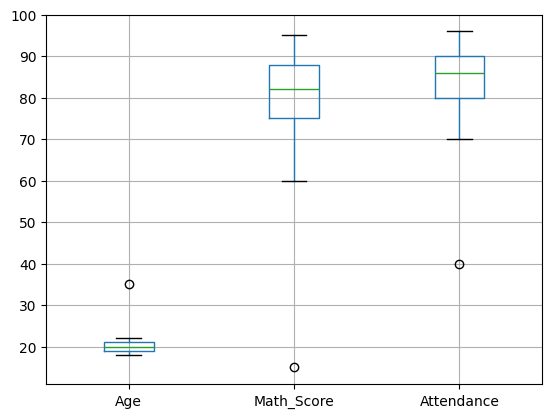

In [ ]:
col = ['Age', 'Math_Score', 'Attendance'] # Boxplot for each column to visualize outliers

df.boxplot(col)

plt.show()

In [ ]:
z = np.abs(stats.zscore(df[['Age', # Calculate Z-scores for 'Age', 
                            'Math_Score',
                            'Attendance']]))

print(z)

[[6.95162317e-01 4.46560003e-02 1.10691826e-01]
 [3.87686677e-01 4.04695003e-01 5.65318967e-01]
 [8.02110366e-02 7.25660005e-01 3.83468110e-01]
 [6.95162317e-01 8.79165006e-01 7.98562457e-01]
 [2.27264604e-01 5.97274004e-01 1.29212805e-15]
 [3.87686677e-01 4.29814003e-01 3.43935316e-01]
 [0.00000000e+00 0.00000000e+00 7.47169823e-01]
 [8.02110366e-02 8.37300006e-02 4.74393539e-01]
 [6.95162317e-01 2.37235002e-01 5.25786172e-01]
 [5.34740244e-01 8.54046006e-01 1.01994611e+00]
 [3.87686677e-01 6.61467004e-01 6.56244395e-01]
 [8.02110366e-02 3.40502002e-01 2.92542682e-01]
 [2.27264604e-01 7.89853005e-01 8.38095252e-01]
 [6.95162317e-01 1.20013001e+00 1.25318960e+00]
 [3.87686677e-01 1.08849001e-01 1.62084459e-01]
 [0.00000000e+00 2.12116001e-01 1.10691826e-01]
 [8.02110366e-02 4.68888003e-01 1.29212805e-15]
 [2.27264604e-01 0.00000000e+00 5.65318967e-01]
 [6.95162317e-01 3.65621002e-01 7.07637028e-01]
 [4.53192357e+00 4.08881503e+00 3.98095245e+00]
 [3.87686677e-01 5.97274004e-01 3.834681

In [ ]:
threshold = 2 # Define a threshold for identifying outliers (commonly set to 2 or 3)

outliers = np.where(z > threshold) # Get the indices of the outliers based on the Z-score threshold

outliers

(array([19, 19, 19], dtype=int64), array([0, 1, 2], dtype=int64))

In [ ]:
Q1 = df['Math_Score'].quantile(0.25) # Calculate the first quartile (Q1) for 'Math_Score'

Q3 = df['Math_Score'].quantile(0.75) # Calculate the third quartile (Q3) for 'Math_Score'

IQR = Q3 - Q1 # Calculate the interquartile range (IQR) for 'Math_Score'

print(Q1)
print(Q3)
print(IQR)

75.0
88.0
13.0


In [16]:
lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

print(lower_bound)
print(upper_bound)

55.5
107.5


In [ ]:
math_outliers = df[(df['Math_Score'] < lower_bound) | # Identify outliers in 'Math_Score' based on the calculated bounds
                   (df['Math_Score'] > upper_bound)] 

math_outliers

,Student_ID,Age,Gender,Math_Score,Attendance
19,20,35.0,M,15.0,40.0


In [ ]:
median_value = df['Math_Score'].median() # Calculate the median value of 'Math_Score' to replace outliers

median_value

82.0

In [ ]:
df['Math_Score'] = np.where(df['Math_Score'] < lower_bound, # Replace outliers below the lower bound with the median value
                            median_value, # Replace outliers above the upper bound with the median value
                            df['Math_Score']) # Replace outliers above the upper bound with the median value

df

,Student_ID,Age,Gender,Math_Score,Attendance
0,1,18.00000,M,78.000000,85.000000
1,2,19.00000,F,85.000000,90.000000
2,3,20.00000,F,90.000000,88.000000
3,4,18.00000,M,65.000000,75.000000
4,5,21.00000,F,88.000000,83.782609
5,6,19.00000,M,72.000000,80.000000
6,7,20.26087,M,78.695652,92.000000
7,8,20.00000,F,80.000000,89.000000
8,9,18.00000,M,75.000000,78.000000
9,10,22.00000,F,92.000000,95.000000


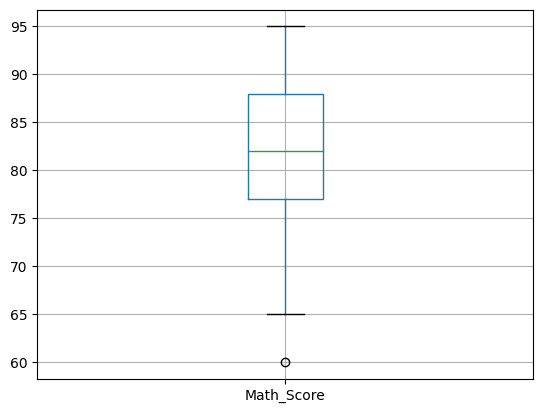

In [ ]:
df.boxplot(['Math_Score']) # Boxplot for 'Math_Score' after handling outliers to visualize the effect

plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder() # Create an instance of LabelEncoder

df['Gender'] = label_encoder.fit_transform(df['Gender']) # Encode 'Gender' column to numeric values 

df

,Student_ID,Age,Gender,Math_Score,Attendance
0,1,18.00000,1,78.000000,85.000000
1,2,19.00000,0,85.000000,90.000000
2,3,20.00000,0,90.000000,88.000000
3,4,18.00000,1,65.000000,75.000000
4,5,21.00000,0,88.000000,83.782609
5,6,19.00000,1,72.000000,80.000000
6,7,20.26087,1,78.695652,92.000000
7,8,20.00000,0,80.000000,89.000000
8,9,18.00000,1,75.000000,78.000000
9,10,22.00000,0,92.000000,95.000000


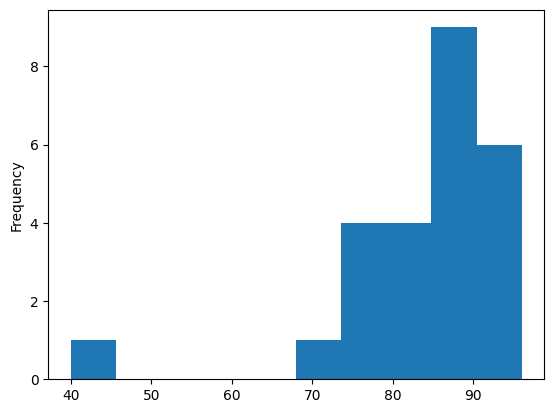

In [ ]:
df['Attendance'].plot(kind='hist') # Plot histogram of 'Attendance' to check for normality

plt.show()

In [ ]:
df['Log_Attendance'] = np.log10(df['Attendance']) # Apply log transformation to 'Attendance' to reduce skewness

df

,Student_ID,Age,Gender,Math_Score,Attendance,Log_Attendance
0,1,18.00000,1,78.000000,85.000000,1.929419
1,2,19.00000,0,85.000000,90.000000,1.954243
2,3,20.00000,0,90.000000,88.000000,1.944483
3,4,18.00000,1,65.000000,75.000000,1.875061
4,5,21.00000,0,88.000000,83.782609,1.923154
5,6,19.00000,1,72.000000,80.000000,1.903090
6,7,20.26087,1,78.695652,92.000000,1.963788
7,8,20.00000,0,80.000000,89.000000,1.949390
8,9,18.00000,1,75.000000,78.000000,1.892095
9,10,22.00000,0,92.000000,95.000000,1.977724


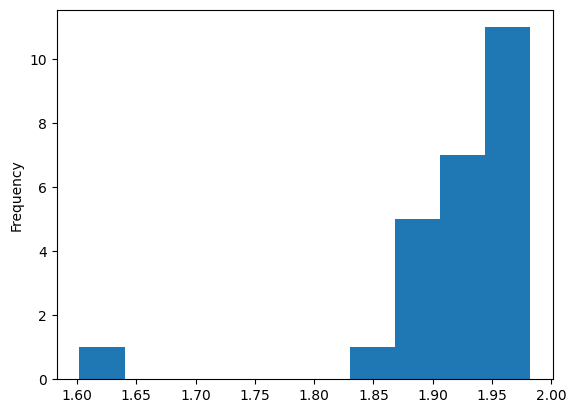

In [ ]:
df['Log_Attendance'].plot(kind='hist') # Plot histogram of log-transformed 'Attendance' to check for normality

plt.show()

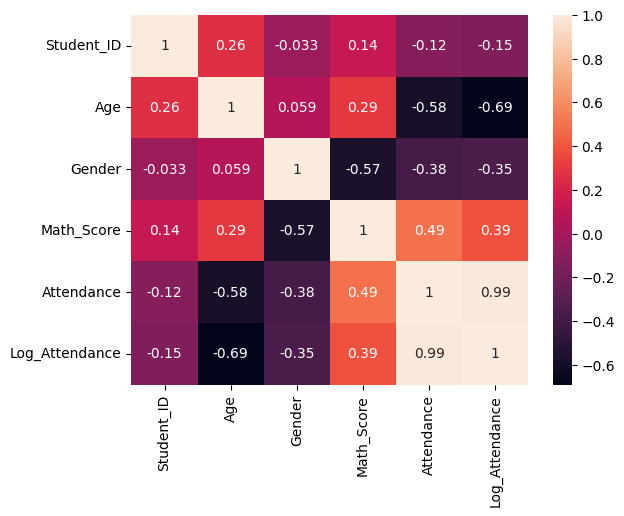

In [ ]:
sns.heatmap(df.corr(numeric_only=True), # Compute correlation matrix for numeric columns and create a heatmap
            annot=True) # Annotate the heatmap with correlation values

plt.show()

In [26]:
df

,Student_ID,Age,Gender,Math_Score,Attendance,Log_Attendance
0,1,18.00000,1,78.000000,85.000000,1.929419
1,2,19.00000,0,85.000000,90.000000,1.954243
2,3,20.00000,0,90.000000,88.000000,1.944483
3,4,18.00000,1,65.000000,75.000000,1.875061
4,5,21.00000,0,88.000000,83.782609,1.923154
5,6,19.00000,1,72.000000,80.000000,1.903090
6,7,20.26087,1,78.695652,92.000000,1.963788
7,8,20.00000,0,80.000000,89.000000,1.949390
8,9,18.00000,1,75.000000,78.000000,1.892095
9,10,22.00000,0,92.000000,95.000000,1.977724
